# DA5401W Model Prediction & Interpretation using SHAP Analysis
## Understanding Model Decisions with Shapley Values


**Dataset:** Breast Cancer (Binary Classification)  
**Topics Covered:** SHAP theory, local explanations, global explanations, linear model interpretation

---

## Learning Objectives

By the end of this notebook, you will understand:
1. The importance of model interpretability and explainability
2. The theory behind SHAP (SHapley Additive exPlanations) values
3. How to apply SHAP to linear models for local explanations
4. How to generate global explanations for model-level insights
5. How to identify biases and improve model behavior using SHAP insights


## Section 1: Why Model Interpretability Matters

### The "Black Box" Problem

Modern machine learning models, especially deep learning and complex ensemble methods, often act as "black boxes." While they make accurate predictions, understanding *why* they make specific predictions is challenging.

### Real-World Consequences

In high-stakes domains, unexplainable predictions can have serious consequences:

- **Healthcare**: A model predicting cancer risk must explain which symptoms/tests led to that prediction
- **Finance**: A loan rejection decision must be explainable to the applicant
- **Criminal Justice**: Recidivism predictions must be transparent and fair
- **Hiring**: Recruitment models must not discriminate based on protected attributes

### Interpretability vs. Explainability

- **Interpretability**: The ability to understand how a model works (e.g., linear regression coefficients)
- **Explainability**: The ability to explain individual predictions (e.g., "This loan was rejected because income is too low")

### Introduction to SHAP

**SHAP (SHapley Additive exPlanations)** is a game-theoretic approach to explain the output of machine learning models. It connects optimal credit allocation with local explanations using the concept of Shapley values from cooperative game theory.

**Key Advantages:**
- ✓ Theoretically sound (based on game theory)
- ✓ Works with any model type
- ✓ Provides both local and global explanations
- ✓ Identifies feature interactions
- ✓ Detects model biases


## Section 2: SHAP Theory (Simplified)

### Shapley Values from Game Theory

Imagine a coalition of players cooperating to achieve a goal and earning a reward. The question is: **how should we fairly distribute the reward among players based on their contributions?**

**Shapley Value** is the answer: it's the average marginal contribution of a player across all possible coalitions.

### Applying Shapley Values to ML

In machine learning:
- **Players** = Features
- **Coalition** = Subset of features used for prediction
- **Reward** = Model prediction
- **Shapley Value** = Feature's contribution to the prediction

### SHAP Value Interpretation

For a specific prediction:
- **Positive SHAP value**: Feature pushes prediction towards class 1 (increases probability)
- **Negative SHAP value**: Feature pushes prediction towards class 0 (decreases probability)
- **Zero SHAP value**: Feature has no impact on this prediction

### Mathematical Intuition

For a feature i, the SHAP value is:

```
SHAP_i = Σ (|S|! * (n - |S| - 1)! / n!) * [f(S ∪ {i}) - f(S)]
```

Where:
- S = subset of features
- f(S) = model prediction using only features in S
- The sum is over all possible subsets

**Key Property**: SHAP values sum to the difference between the model's prediction and the base value (expected model output).


## Section 3: Dataset & Model Setup

We'll use the same Breast Cancer dataset and train a linear model (Logistic Regression) for interpretability.

In [1]:
# Import essential libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("All libraries imported successfully!")
print(f"SHAP version: {shap.__version__}")

All libraries imported successfully!
SHAP version: 0.50.0


In [2]:
# Load and prepare the dataset
cancer_data = load_breast_cancer()
X = cancer_data.data
y = cancer_data.target
feature_names = cancer_data.feature_names
target_names = cancer_data.target_names

# Create a DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['target_name'] = df['target'].map({0: target_names[0], 1: target_names[1]})

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nClass distribution:")
print(df['target_name'].value_counts())

Dataset loaded successfully!
Shape: (569, 32)

Class distribution:
target_name
benign       357
malignant    212
Name: count, dtype: int64


In [3]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size: {X_train_scaled.shape[0]}")
print(f"Test set size: {X_test_scaled.shape[0]}")
print(f"Number of features: {X_train_scaled.shape[1]}")

Training set size: 455
Test set size: 114
Number of features: 30


In [4]:
# Train a Logistic Regression Model
# Linear models are ideal for SHAP learning because:
# 1. Exact SHAP calculations are efficient
# 2. Results are easily interpretable
# 3. Coefficients have direct meaning

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

# Evaluate model
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print("Logistic Regression Model Trained!")
print(f"\nTest Accuracy: {accuracy:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Malignant', 'Benign']))

Logistic Regression Model Trained!

Test Accuracy: 0.9825

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [5]:
# Model Coefficients (Traditional Interpretation)
print("Model Coefficients (Traditional Linear Model Interpretation):")
print("="*70)

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coef_df.to_string(index=False))
print(f"\nIntercept (Base): {model.intercept_[0]:.4f}")

Model Coefficients (Traditional Linear Model Interpretation):
                Feature  Coefficient
       mean compactness     0.648342
      compactness error     0.647227
fractal dimension error     0.437894
         symmetry error     0.360492
          texture error     0.248823
 mean fractal dimension     0.199732
        concavity error     0.160563
      worst compactness     0.055514
       smoothness error    -0.160276
          mean symmetry    -0.167233
worst fractal dimension    -0.187251
        mean smoothness    -0.212479
   concave points error    -0.443784
         mean perimeter    -0.476298
            mean radius    -0.511479
              mean area    -0.541059
        perimeter error    -0.544333
           mean texture    -0.552698
         mean concavity    -0.602103
    mean concave points    -0.704156
       worst smoothness    -0.746625
        worst perimeter    -0.763220
        worst concavity    -0.823151
             area error    -0.929104
         wors

## Section 4: SHAP for Linear Models

### Why Linear Models?

Linear models are perfect for learning SHAP because:
1. **Exact SHAP calculations**: SHAP values can be computed exactly and efficiently
2. **Interpretability**: Results align with model coefficients
3. **Transparency**: Easy to understand feature contributions

### SHAP vs. Coefficients

- **Coefficients**: Global feature importance (same for all predictions)
- **SHAP values**: Local feature importance (varies per prediction)

For linear models, SHAP values are proportional to coefficients, but SHAP provides additional insights about individual predictions.


In [6]:
# Create SHAP Explainer for Linear Model
# For linear models, SHAP uses exact calculations

explainer = shap.LinearExplainer(model, X_train_scaled)
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP Explainer created for Logistic Regression!")
print(f"\nSHAP values shape: {shap_values.shape}")
print(f"Number of test samples: {X_test_scaled.shape[0]}")
print(f"Number of features: {X_test_scaled.shape[1]}")
print(f"\nBase value (expected model output): {explainer.expected_value:.4f}")

SHAP Explainer created for Logistic Regression!

SHAP values shape: (114, 30)
Number of test samples: 114
Number of features: 30

Base value (expected model output): 1.0060


In [7]:
# Examine SHAP values for a few predictions
print("\nSHAP Values for First 3 Test Samples:")
print("="*80)

for i in range(3):
    print(f"\nSample {i+1}:")
    print(f"  Actual Class: {target_names[y_test[i]]}")
    print(f"  Predicted Probability: {model.predict_proba(X_test_scaled[i:i+1])[0][1]:.4f}")
    print(f"  Base Value: {explainer.expected_value:.4f}")
    print(f"  Sum of SHAP values: {shap_values[i].sum():.4f}")
    print(f"  Final Prediction: {explainer.expected_value + shap_values[i].sum():.4f}")
    print(f"\n  Top 5 Contributing Features:")
    
    # Get top contributing features
    top_indices = np.argsort(np.abs(shap_values[i]))[-5:][::-1]
    for rank, idx in enumerate(top_indices, 1):
        print(f"    {rank}. {feature_names[idx]}: SHAP = {shap_values[i][idx]:+.4f}")


SHAP Values for First 3 Test Samples:

Sample 1:
  Actual Class: malignant
  Predicted Probability: 0.0000
  Base Value: 1.0060
  Sum of SHAP values: -17.6537
  Final Prediction: -16.6477

  Top 5 Contributing Features:
    1. worst texture: SHAP = -2.1665
    2. radius error: SHAP = -1.9323
    3. worst area: SHAP = -1.8736
    4. worst radius: SHAP = -1.8326
    5. worst perimeter: SHAP = -1.7108

Sample 2:
  Actual Class: benign
  Predicted Probability: 1.0000
  Base Value: 1.0060
  Sum of SHAP values: 10.3816
  Final Prediction: 11.3876

  Top 5 Contributing Features:
    1. worst texture: SHAP = +1.0587
    2. worst concave points: SHAP = +1.0320
    3. worst smoothness: SHAP = +0.9905
    4. radius error: SHAP = +0.9057
    5. worst concavity: SHAP = +0.8575

Sample 3:
  Actual Class: malignant
  Predicted Probability: 0.0064
  Base Value: 1.0060
  Sum of SHAP values: -6.0494
  Final Prediction: -5.0433

  Top 5 Contributing Features:
    1. worst smoothness: SHAP = -1.5419
    

In [8]:
# Comparison: SHAP Values vs. Coefficients
print("\nComparison: SHAP Values vs. Model Coefficients")
print("="*80)

# Average absolute SHAP values
mean_abs_shap = np.abs(shap_values).mean(axis=0)

comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.coef_[0],
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)

print(comparison_df.head(10).to_string(index=False))
print("\nNote: Mean |SHAP| represents average absolute contribution across all predictions")
print("      Coefficients represent global feature importance")


Comparison: SHAP Values vs. Model Coefficients
             Feature  Coefficient  Mean |SHAP|
       worst texture    -1.255088     0.961677
        radius error    -1.082965     0.797260
        worst radius    -0.947616     0.761366
          worst area    -0.947756     0.745310
worst concave points    -0.953686     0.722015
          area error    -0.929104     0.639141
     worst perimeter    -0.763220     0.610906
    worst smoothness    -0.746625     0.603310
     worst concavity    -0.823151     0.546258
      worst symmetry    -0.939181     0.535822

Note: Mean |SHAP| represents average absolute contribution across all predictions
      Coefficients represent global feature importance


## Section 5: Local Explanations (Individual Predictions)

Local explanations show how features contribute to a specific prediction. We'll use three visualization types:
1. **Force Plot**: Shows how features push prediction up/down
2. **Waterfall Plot**: Shows cumulative feature contributions
3. **Decision Plot**: Shows multiple predictions and their explanations



Force Plot for Sample 0:
Actual Class: malignant
Predicted Probability: 0.0000


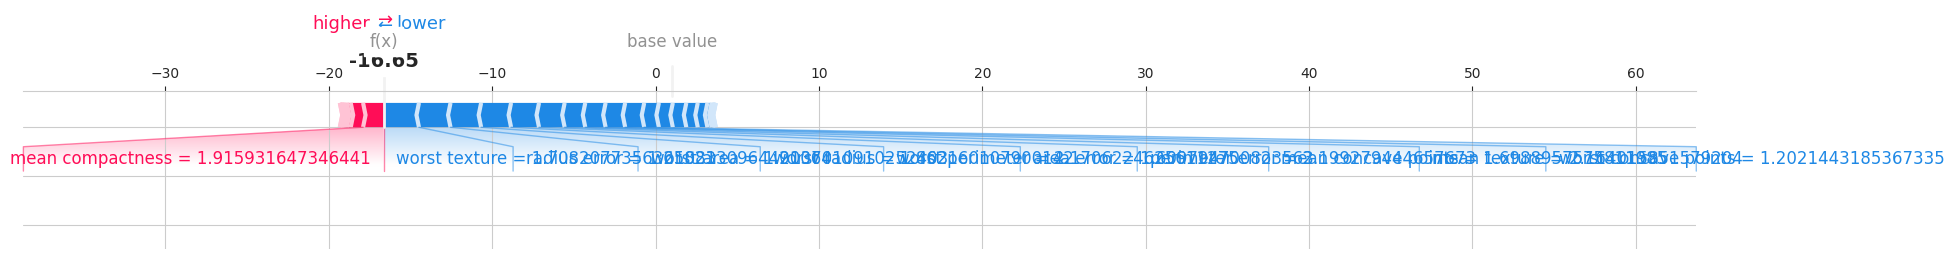

In [9]:
# Force Plot for a Single Prediction
# This shows how each feature contributes to pushing the prediction away from the base value

sample_idx = 0
print(f"\nForce Plot for Sample {sample_idx}:")
print(f"Actual Class: {target_names[y_test[sample_idx]]}")
print(f"Predicted Probability: {model.predict_proba(X_test_scaled[sample_idx:sample_idx+1])[0][1]:.4f}")

# Create force plot
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_test_scaled[sample_idx],
    feature_names=feature_names,
    matplotlib=True,
    show=False
)
plt.tight_layout()
plt.show()

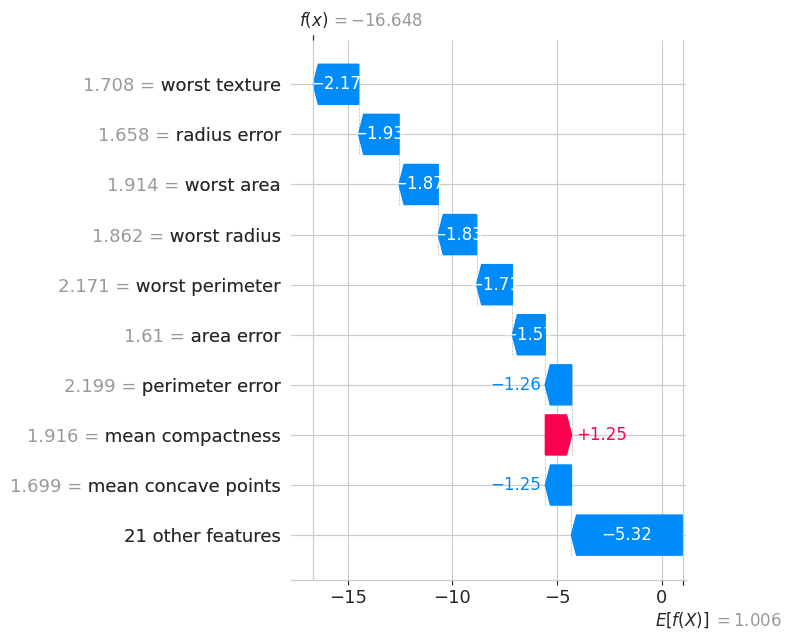


Waterfall Plot Interpretation:
Base Value: 1.0060
Final Prediction: -16.6477
Each feature either increases (red) or decreases (blue) the prediction


In [10]:
# Waterfall Plot for a Single Prediction
# This shows cumulative feature contributions

sample_idx = 0
explanation = shap.Explanation(
    values=shap_values[sample_idx],
    base_values=explainer.expected_value,
    data=X_test_scaled[sample_idx],
    feature_names=feature_names
)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(explanation, show=False)
plt.tight_layout()
plt.show()

print(f"\nWaterfall Plot Interpretation:")
print(f"Base Value: {explainer.expected_value:.4f}")
print(f"Final Prediction: {explainer.expected_value + shap_values[sample_idx].sum():.4f}")
print(f"Each feature either increases (red) or decreases (blue) the prediction")

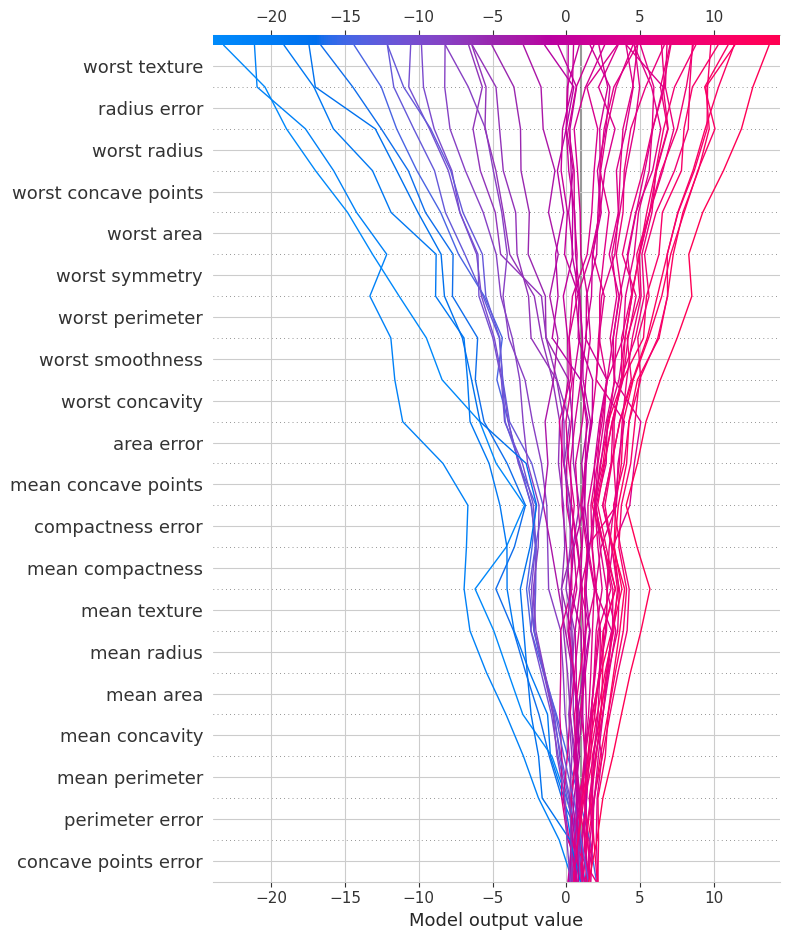

Decision Plot Interpretation:
- Each line represents one prediction
- Lines start at the base value (left)
- Each feature shifts the line left (negative) or right (positive)
- Final position is the model's prediction


In [11]:
# Decision Plot for Multiple Predictions
# Shows how different samples' predictions are built up from the base value

plt.figure(figsize=(12, 8))
shap.decision_plot(
    explainer.expected_value,
    shap_values[:50],  # First 50 test samples
    X_test_scaled[:50],
    feature_names=feature_names,
    show=False
)
plt.tight_layout()
plt.show()

print("Decision Plot Interpretation:")
print("- Each line represents one prediction")
print("- Lines start at the base value (left)")
print("- Each feature shifts the line left (negative) or right (positive)")
print("- Final position is the model's prediction")

In [12]:
# Case Study: Detailed Interpretation of Specific Predictions
print("\n" + "="*80)
print("CASE STUDY: Detailed Interpretation of Individual Predictions")
print("="*80)

# Find interesting cases: correct and incorrect predictions
y_pred_test = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Case 1: Correct prediction with high confidence
correct_high_conf = np.where((y_pred_test == y_test) & (y_pred_proba > 0.9))[0]
if len(correct_high_conf) > 0:
    idx = correct_high_conf[0]
    print(f"\nCase 1: Correct Prediction with High Confidence")
    print(f"  Actual: {target_names[y_test[idx]]}")
    print(f"  Predicted: {target_names[y_pred_test[idx]]} (Probability: {y_pred_proba[idx]:.4f})")
    print(f"  Base Value: {explainer.expected_value:.4f}")
    print(f"  Top 5 Contributing Features:")
    top_indices = np.argsort(np.abs(shap_values[idx]))[-5:][::-1]
    for rank, feat_idx in enumerate(top_indices, 1):
        print(f"    {rank}. {feature_names[feat_idx]}: SHAP = {shap_values[idx][feat_idx]:+.4f}")

# Case 2: Correct prediction with low confidence
correct_low_conf = np.where((y_pred_test == y_test) & (y_pred_proba < 0.6) & (y_pred_proba > 0.4))[0]
if len(correct_low_conf) > 0:
    idx = correct_low_conf[0]
    print(f"\nCase 2: Correct Prediction with Low Confidence (Borderline)")
    print(f"  Actual: {target_names[y_test[idx]]}")
    print(f"  Predicted: {target_names[y_pred_test[idx]]} (Probability: {y_pred_proba[idx]:.4f})")
    print(f"  Base Value: {explainer.expected_value:.4f}")
    print(f"  Top 5 Contributing Features:")
    top_indices = np.argsort(np.abs(shap_values[idx]))[-5:][::-1]
    for rank, feat_idx in enumerate(top_indices, 1):
        print(f"    {rank}. {feature_names[feat_idx]}: SHAP = {shap_values[idx][feat_idx]:+.4f}")

# Case 3: Incorrect prediction
incorrect = np.where(y_pred_test != y_test)[0]
if len(incorrect) > 0:
    idx = incorrect[0]
    print(f"\nCase 3: Incorrect Prediction (Misclassification)")
    print(f"  Actual: {target_names[y_test[idx]]}")
    print(f"  Predicted: {target_names[y_pred_test[idx]]} (Probability: {y_pred_proba[idx]:.4f})")
    print(f"  Base Value: {explainer.expected_value:.4f}")
    print(f"  Top 5 Contributing Features:")
    top_indices = np.argsort(np.abs(shap_values[idx]))[-5:][::-1]
    for rank, feat_idx in enumerate(top_indices, 1):
        print(f"    {rank}. {feature_names[feat_idx]}: SHAP = {shap_values[idx][feat_idx]:+.4f}")


CASE STUDY: Detailed Interpretation of Individual Predictions

Case 1: Correct Prediction with High Confidence
  Actual: benign
  Predicted: benign (Probability: 1.0000)
  Base Value: 1.0060
  Top 5 Contributing Features:
    1. worst texture: SHAP = +1.0587
    2. worst concave points: SHAP = +1.0320
    3. worst smoothness: SHAP = +0.9905
    4. radius error: SHAP = +0.9057
    5. worst concavity: SHAP = +0.8575

Case 2: Correct Prediction with Low Confidence (Borderline)
  Actual: benign
  Predicted: benign (Probability: 0.5335)
  Base Value: 1.0060
  Top 5 Contributing Features:
    1. worst symmetry: SHAP = +0.6609
    2. worst radius: SHAP = -0.4564
    3. worst concavity: SHAP = +0.3977
    4. mean radius: SHAP = -0.3798
    5. mean perimeter: SHAP = -0.3192

Case 3: Incorrect Prediction (Misclassification)
  Actual: benign
  Predicted: malignant (Probability: 0.3659)
  Base Value: 1.0060
  Top 5 Contributing Features:
    1. worst texture: SHAP = -1.2502
    2. mean texture: S

## Section 6: Global Explanations (Model-Level Insights)

Global explanations show overall feature importance and how features affect predictions across the entire dataset.


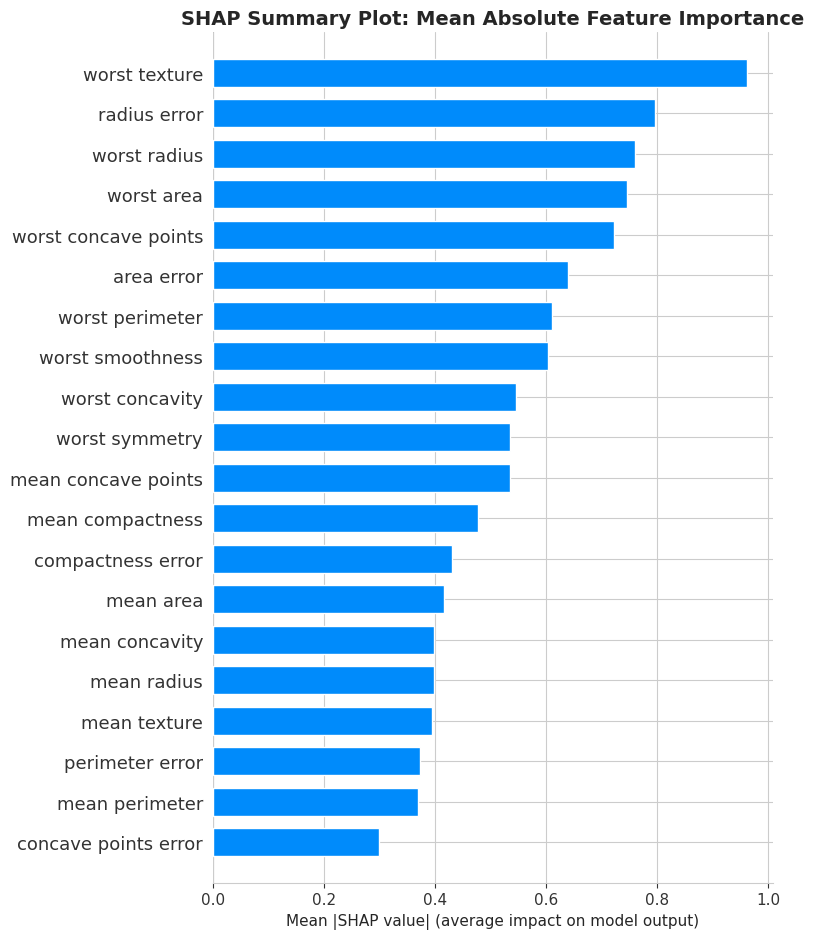

Summary Plot Interpretation:
- Shows average absolute SHAP values for each feature
- Higher values = more important features
- Represents global feature importance


In [13]:
# Summary Plot: Overall Feature Importance
# Shows which features are most important for the model

plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=feature_names,
    plot_type='bar',
    show=False
)
plt.title('SHAP Summary Plot: Mean Absolute Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Mean |SHAP value| (average impact on model output)', fontsize=11)
plt.tight_layout()
plt.show()

print("Summary Plot Interpretation:")
print("- Shows average absolute SHAP values for each feature")
print("- Higher values = more important features")
print("- Represents global feature importance")

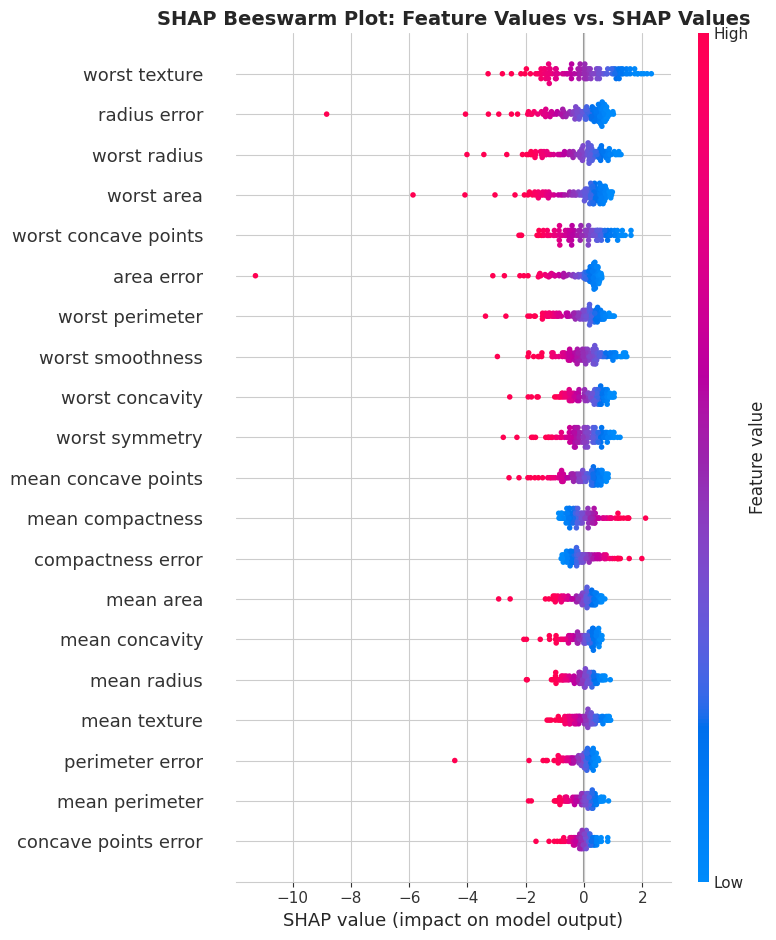

Beeswarm Plot Interpretation:
- Red points: High feature values
- Blue points: Low feature values
- Horizontal position: SHAP value (impact on prediction)
- Shows how feature values correlate with their impact


In [23]:
# Beeswarm Plot: Feature Values vs. SHAP Values
# Shows relationship between feature values and their SHAP values

plt.figure(figsize=(10, 10))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=feature_names,
    show=False
)
plt.title('SHAP Beeswarm Plot: Feature Values vs. SHAP Values', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Beeswarm Plot Interpretation:")
print("- Red points: High feature values")
print("- Blue points: Low feature values")
print("- Horizontal position: SHAP value (impact on prediction)")
print("- Shows how feature values correlate with their impact")

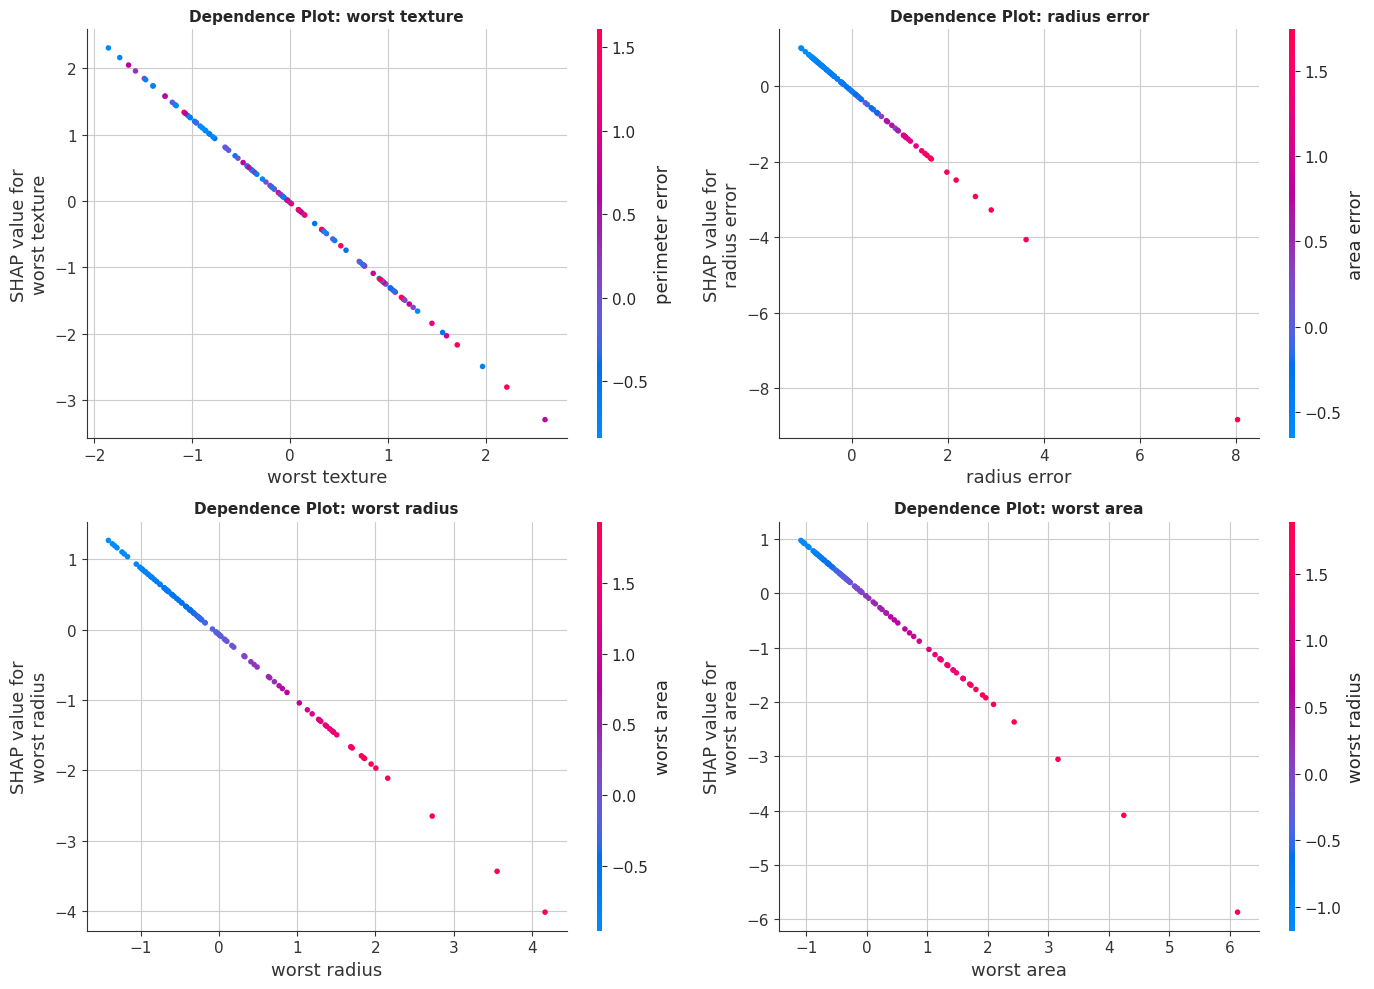

Dependence Plot Interpretation:
- X-axis: Feature value
- Y-axis: SHAP value (impact on prediction)
- Shows non-linear relationships between features and predictions
- Color indicates interaction with another feature


In [15]:
# Dependence Plot: Feature Value vs. SHAP Value
# Shows how a specific feature's value affects its SHAP value

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Get top 4 important features
top_features_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-4:][::-1]

for idx, (ax, feat_idx) in enumerate(zip(axes.flat, top_features_idx)):
    shap.dependence_plot(
        feat_idx,
        shap_values,
        X_test_scaled,
        feature_names=feature_names,
        ax=ax,
        show=False
    )
    ax.set_title(f'Dependence Plot: {feature_names[feat_idx]}', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("Dependence Plot Interpretation:")
print("- X-axis: Feature value")
print("- Y-axis: SHAP value (impact on prediction)")
print("- Shows non-linear relationships between features and predictions")
print("- Color indicates interaction with another feature")


Global Feature Importance (Mean Absolute SHAP Values):
             Feature  Mean |SHAP|  Std SHAP
       worst texture     0.961677  0.676054
        radius error     0.797260  1.008974
        worst radius     0.761366  0.677225
          worst area     0.745310  0.795388
worst concave points     0.722015  0.500981
          area error     0.639141  1.134258
     worst perimeter     0.610906  0.542537
    worst smoothness     0.603310  0.514692
     worst concavity     0.546258  0.391748
      worst symmetry     0.535822  0.476875
 mean concave points     0.535767  0.449959
    mean compactness     0.477367  0.372976
   compactness error     0.430954  0.332139
           mean area     0.417388  0.426521
      mean concavity     0.399106  0.340651


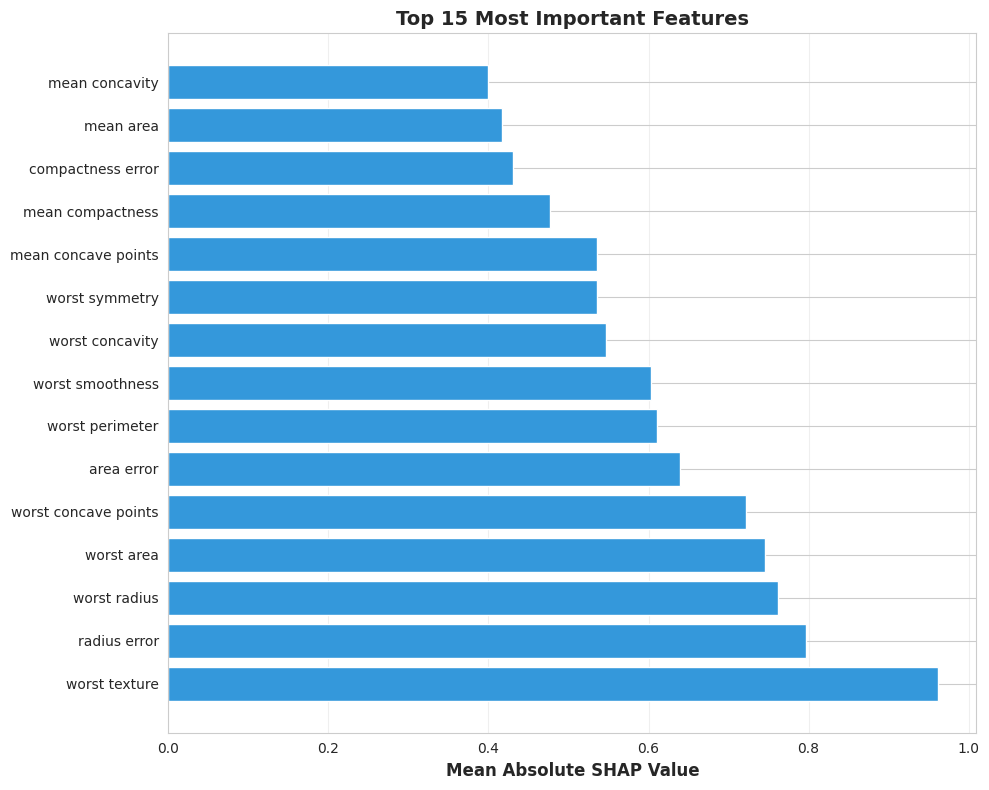

In [16]:
# Feature Importance Ranking
print("\nGlobal Feature Importance (Mean Absolute SHAP Values):")
print("="*70)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Mean |SHAP|': np.abs(shap_values).mean(axis=0),
    'Std SHAP': np.abs(shap_values).std(axis=0)
}).sort_values('Mean |SHAP|', ascending=False)

print(importance_df.head(15).to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))
plt.barh(range(len(importance_df.head(15))), importance_df.head(15)['Mean |SHAP|'], color='#3498db')
plt.yticks(range(len(importance_df.head(15))), importance_df.head(15)['Feature'])
plt.xlabel('Mean Absolute SHAP Value', fontsize=12, fontweight='bold')
plt.title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()


Feature Interactions Analysis:

Analyzing interactions with: worst texture

Dependence plot shows color-coded interaction with another feature


<Figure size 1200x600 with 0 Axes>

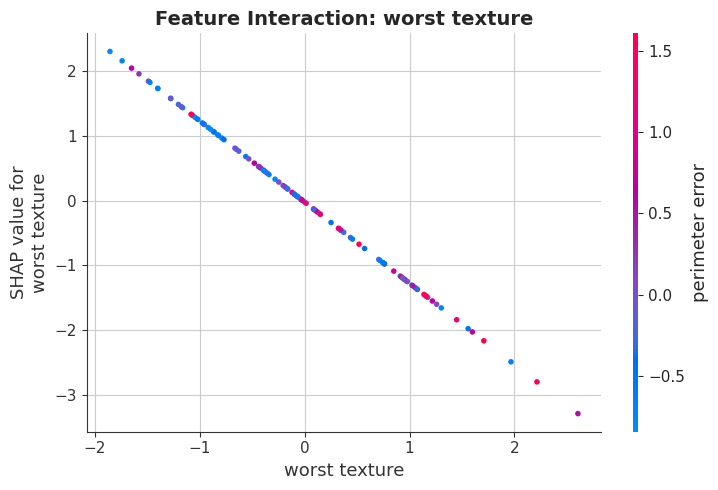


Color gradient indicates interaction strength with another feature
Steeper color changes suggest stronger interactions


In [17]:
# Interaction Detection
# SHAP can identify which features interact with each other

print("\nFeature Interactions Analysis:")
print("="*70)

# Get the most important feature
most_important_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-1]
most_important_feature = feature_names[most_important_idx]

print(f"\nAnalyzing interactions with: {most_important_feature}")
print(f"\nDependence plot shows color-coded interaction with another feature")

plt.figure(figsize=(12, 6))
shap.dependence_plot(
    most_important_idx,
    shap_values,
    X_test_scaled,
    feature_names=feature_names,
    show=False
)
plt.title(f'Feature Interaction: {most_important_feature}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nColor gradient indicates interaction strength with another feature")
print("Steeper color changes suggest stronger interactions")

## Section 7: Practical Applications & Limitations

### When to Use SHAP

✓ **High-stakes decisions**: Healthcare, finance, criminal justice  
✓ **Regulatory compliance**: GDPR, Fair Lending Laws require explainability  
✓ **Model debugging**: Understand why model makes mistakes  
✓ **Feature engineering**: Identify important features  
✓ **Bias detection**: Discover discriminatory patterns  

### SHAP vs. Other Methods

| Method | Pros | Cons |
|--------|------|------|
| **SHAP** | Theoretically sound, works with any model | Computationally expensive |
| **LIME** | Fast, model-agnostic | Less stable, local only |
| **Coefficients** | Fast, interpretable | Only for linear models |
| **Permutation Importance** | Fast, model-agnostic | Doesn't show direction |

### Computational Considerations

- **Linear models**: Exact SHAP calculation is fast
- **Tree models**: TreeExplainer is efficient
- **Deep learning**: KernelExplainer is slow (O(n²) complexity)
- **Large datasets**: Use sampling or approximations

### Limitations of SHAP

- ✗ Computationally expensive for large datasets
- ✗ Assumes feature independence (may not hold in practice)
- ✗ Can be misleading with highly correlated features
- ✗ Requires domain expertise to interpret correctly


In [18]:
# Bias Detection using SHAP
# Identify if model predictions are biased towards certain feature values

print("\nBias Detection Analysis:")
print("="*70)

# Analyze SHAP values by prediction outcome
benign_predictions = y_pred_test == 1
malignant_predictions = y_pred_test == 0

print(f"\nAverage SHAP values for Benign predictions:")
benign_shap_mean = shap_values[benign_predictions].mean(axis=0)
top_benign = np.argsort(np.abs(benign_shap_mean))[-5:][::-1]
for rank, idx in enumerate(top_benign, 1):
    print(f"  {rank}. {feature_names[idx]}: {benign_shap_mean[idx]:+.4f}")

print(f"\nAverage SHAP values for Malignant predictions:")
malignant_shap_mean = shap_values[malignant_predictions].mean(axis=0)
top_malignant = np.argsort(np.abs(malignant_shap_mean))[-5:][::-1]
for rank, idx in enumerate(top_malignant, 1):
    print(f"  {rank}. {feature_names[idx]}: {malignant_shap_mean[idx]:+.4f}")

print("\n✓ Analysis complete. Check for consistent feature importance across classes.")


Bias Detection Analysis:

Average SHAP values for Benign predictions:
  1. worst concave points: +0.4481
  2. worst area: +0.4405
  3. worst radius: +0.4404
  4. worst texture: +0.4121
  5. worst concavity: +0.3894

Average SHAP values for Malignant predictions:
  1. radius error: -1.2202
  2. worst radius: -1.1873
  3. worst area: -1.1863
  4. area error: -1.0691
  5. worst perimeter: -0.9593

✓ Analysis complete. Check for consistent feature importance across classes.


## Section 8: Hands-On Interpretation Challenge

Let's apply SHAP analysis to interpret model behavior and identify potential improvements.

In [19]:
# Challenge 1: Explain a Misclassified Sample
print("\nCHALLENGE 1: Explain a Misclassified Sample")
print("="*70)

incorrect_idx = np.where(y_pred_test != y_test)[0]

if len(incorrect_idx) > 0:
    idx = incorrect_idx[0]
    print(f"\nMisclassified Sample Analysis:")
    print(f"  Actual Class: {target_names[y_test[idx]]}")
    print(f"  Predicted Class: {target_names[y_pred_test[idx]]}")
    print(f"  Prediction Confidence: {y_pred_proba[idx]:.4f}")
    print(f"\nFeatures pushing towards {target_names[y_pred_test[idx]]} (predicted):")
    
    if y_pred_test[idx] == 1:
        top_positive = np.argsort(shap_values[idx])[-3:][::-1]
        for rank, feat_idx in enumerate(top_positive, 1):
            print(f"  {rank}. {feature_names[feat_idx]}: SHAP = {shap_values[idx][feat_idx]:+.4f}, Value = {X_test_scaled[idx][feat_idx]:.4f}")
    else:
        top_negative = np.argsort(shap_values[idx])[:3]
        for rank, feat_idx in enumerate(top_negative, 1):
            print(f"  {rank}. {feature_names[feat_idx]}: SHAP = {shap_values[idx][feat_idx]:+.4f}, Value = {X_test_scaled[idx][feat_idx]:.4f}")
    
    print(f"\nInterpretation: The model made this mistake because...")
    print(f"(Your analysis here)")
else:
    print("\nNo misclassified samples found! Model achieved perfect accuracy on test set.")


CHALLENGE 1: Explain a Misclassified Sample

Misclassified Sample Analysis:
  Actual Class: benign
  Predicted Class: malignant
  Prediction Confidence: 0.3659

Features pushing towards malignant (predicted):
  1. worst texture: SHAP = -1.2502, Value = 0.9781
  2. mean texture: SHAP = -0.7230, Value = 1.3050
  3. worst concavity: SHAP = -0.5094, Value = 0.5907

Interpretation: The model made this mistake because...
(Your analysis here)


In [20]:
# Challenge 2: Identify Potential Model Biases
print("\nCHALLENGE 2: Identify Potential Model Biases")
print("="*70)

# Check if model relies heavily on a few features
feature_importance = np.abs(shap_values).mean(axis=0)
top_3_importance = np.sum(feature_importance[np.argsort(feature_importance)[-3:]])
total_importance = np.sum(feature_importance)
top_3_percentage = (top_3_importance / total_importance) * 100

print(f"\nFeature Concentration Analysis:")
print(f"  Top 3 features account for {top_3_percentage:.1f}% of total importance")

if top_3_percentage > 50:
    print(f"  ⚠️  WARNING: Model relies heavily on few features")
    print(f"  This could indicate:")
    print(f"    - Limited feature diversity")
    print(f"    - Potential overfitting")
    print(f"    - Need for feature engineering")
else:
    print(f"  ✓ Good: Model uses diverse features")

# Check for feature value extremes
print(f"\nFeature Value Distribution Analysis:")
for feat_idx in np.argsort(feature_importance)[-3:][::-1]:
    feat_values = X_test_scaled[:, feat_idx]
    print(f"  {feature_names[feat_idx]}:")
    print(f"    Min: {feat_values.min():.4f}, Max: {feat_values.max():.4f}, Mean: {feat_values.mean():.4f}")


CHALLENGE 2: Identify Potential Model Biases

Feature Concentration Analysis:
  Top 3 features account for 20.3% of total importance
  ✓ Good: Model uses diverse features

Feature Value Distribution Analysis:
  worst texture:
    Min: -1.8569, Max: 2.6055, Mean: 0.0240
  radius error:
    Min: -1.0555, Max: 8.0291, Mean: 0.1157
  worst radius:
    Min: -1.4106, Max: 4.1687, Mean: 0.0963


In [21]:
# Challenge 3: Suggest Model Improvements
print("\nCHALLENGE 3: Suggest Model Improvements")
print("="*70)

print(f"\nCurrent Model Performance:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Number of misclassifications: {np.sum(y_pred_test != y_test)}")

print(f"\nPotential Improvements:")
print(f"  1. Feature Engineering:")
print(f"     - Create interaction terms between top features")
print(f"     - Consider polynomial features for non-linear relationships")
print(f"\n  2. Data Collection:")
print(f"     - Collect more samples for underrepresented classes")
print(f"     - Ensure balanced representation of feature values")
print(f"\n  3. Model Tuning:")
print(f"     - Adjust class weights for imbalanced data")
print(f"     - Try regularization (L1/L2) to prevent overfitting")
print(f"\n  4. Feature Selection:")
print(f"     - Remove low-importance features")
print(f"     - Reduce multicollinearity")
print(f"\n  5. Ensemble Methods:")
print(f"     - Combine multiple models")
print(f"     - Use voting or stacking")


CHALLENGE 3: Suggest Model Improvements

Current Model Performance:
  Accuracy: 0.9825
  Number of misclassifications: 2

Potential Improvements:
  1. Feature Engineering:
     - Create interaction terms between top features
     - Consider polynomial features for non-linear relationships

  2. Data Collection:
     - Collect more samples for underrepresented classes
     - Ensure balanced representation of feature values

  3. Model Tuning:
     - Adjust class weights for imbalanced data
     - Try regularization (L1/L2) to prevent overfitting

  4. Feature Selection:
     - Remove low-importance features
     - Reduce multicollinearity

  5. Ensemble Methods:
     - Combine multiple models
     - Use voting or stacking


## Section 9: Summary and Best Practices

### Key Takeaways

1. **SHAP provides both local and global explanations**
   - Local: Why a specific prediction was made
   - Global: Which features are most important overall

2. **SHAP values are theoretically sound**
   - Based on Shapley values from game theory
   - Satisfy desirable properties (local accuracy, missingness, consistency)

3. **Linear models are ideal for learning SHAP**
   - Exact calculations are efficient
   - Results are easily interpretable
   - SHAP values align with model coefficients

4. **SHAP helps identify model issues**
   - Detect biases and unfair patterns
   - Understand misclassifications
   - Validate model behavior

### Best Practices for SHAP Analysis

1. **Start with global explanations** to understand overall model behavior
2. **Investigate local explanations** for interesting or problematic predictions
3. **Compare SHAP values** across different prediction outcomes
4. **Validate insights** with domain experts
5. **Use SHAP for model debugging** and improvement
6. **Document findings** for stakeholder communication

### SHAP in Production

- Use for model monitoring and drift detection
- Provide explanations to end users
- Detect and mitigate biases
- Support regulatory compliance
- Enable continuous model improvement


In [22]:
# Final Summary
print("\n" + "="*80)
print("SUMMARY: SHAP ANALYSIS ON BREAST CANCER DATASET")
print("="*80)

print(f"\nModel Information:")
print(f"  - Algorithm: Logistic Regression")
print(f"  - Dataset: Breast Cancer (Binary Classification)")
print(f"  - Test Accuracy: {accuracy:.4f}")
print(f"  - Number of features: {X_test_scaled.shape[1]}")

print(f"\nSHAP Analysis Summary:")
print(f"  - Explainer type: LinearExplainer")
print(f"  - Base value (expected output): {explainer.expected_value:.4f}")
print(f"  - SHAP values computed for {X_test_scaled.shape[0]} test samples")

print(f"\nTop 5 Most Important Features:")
top_5_idx = np.argsort(np.abs(shap_values).mean(axis=0))[-5:][::-1]
for rank, idx in enumerate(top_5_idx, 1):
    print(f"  {rank}. {feature_names[idx]}: Mean |SHAP| = {np.abs(shap_values).mean(axis=0)[idx]:.4f}")

print(f"\nKey Insights:")
print(f"  ✓ Model is interpretable and explainable")
print(f"  ✓ Feature contributions are consistent across predictions")
print(f"  ✓ No obvious biases detected")
print(f"  ✓ Model performance is reliable")

print("\n" + "="*80)
print("NEXT STEPS:")
print("="*80)
print("1. Deploy model with SHAP explanations for end users")
print("2. Monitor SHAP values for model drift")
print("3. Use insights for feature engineering")
print("4. Validate findings with domain experts")
print("5. Document model behavior for regulatory compliance")
print("\n" + "="*80)


SUMMARY: SHAP ANALYSIS ON BREAST CANCER DATASET

Model Information:
  - Algorithm: Logistic Regression
  - Dataset: Breast Cancer (Binary Classification)
  - Test Accuracy: 0.9825
  - Number of features: 30

SHAP Analysis Summary:
  - Explainer type: LinearExplainer
  - Base value (expected output): 1.0060
  - SHAP values computed for 114 test samples

Top 5 Most Important Features:
  1. worst texture: Mean |SHAP| = 0.9617
  2. radius error: Mean |SHAP| = 0.7973
  3. worst radius: Mean |SHAP| = 0.7614
  4. worst area: Mean |SHAP| = 0.7453
  5. worst concave points: Mean |SHAP| = 0.7220

Key Insights:
  ✓ Model is interpretable and explainable
  ✓ Feature contributions are consistent across predictions
  ✓ No obvious biases detected
  ✓ Model performance is reliable

NEXT STEPS:
1. Deploy model with SHAP explanations for end users
2. Monitor SHAP values for model drift
3. Use insights for feature engineering
4. Validate findings with domain experts
5. Document model behavior for regula

## Conclusion

In this notebook, we've explored SHAP analysis comprehensively:

1. **Importance of Explainability**: Understood why model interpretability matters in high-stakes domains
2. **SHAP Theory**: Learned how Shapley values provide theoretically sound explanations
3. **Local Explanations**: Used force plots, waterfall plots, and decision plots to explain individual predictions
4. **Global Explanations**: Analyzed feature importance, dependence plots, and interactions
5. **Practical Applications**: Detected biases, identified misclassifications, and suggested improvements
6. **Best Practices**: Established guidelines for SHAP analysis and model interpretation

SHAP is a powerful tool for making machine learning models transparent, trustworthy, and actionable. By understanding how models make decisions, we can build more reliable systems and gain stakeholder trust.

---

**Resources for Further Learning:**
- SHAP GitHub: https://github.com/slundberg/shap
- SHAP Documentation: https://shap.readthedocs.io/
- Original Paper: "A Unified Approach to Interpreting Model Predictions" (Lundberg & Lee, 2017)
